# Titanic Survival Prediction Project 

##### The goal is to build a model that predicts whether a passenger survived the Titanic disaster based on passenger information such as age, gender, ticket class and fare.

# [1]: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# [2]: Load dataset

In [4]:
df = pd.read_csv('Titanic-Dataset.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


# [3]: data cleaning

#### Missing Value Check

In [6]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


#### Fill Missing Values

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

#### Convert Categorical Data to numerical

In [8]:
df['Sex'] = df['Sex'].map({'male':0,'female':1})
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

#### Select Features

In [10]:
x = df[['Pclass','Sex','Age','Fare']].values
y = df['Survived'].values

# Basic Analysis

In [18]:
print('Total Passangers:',len(df))

total passangers: 891


In [20]:
print('Total Survivors:',df['Survived'].sum())

Total Survivors: 342


In [22]:
print('total Non-Survivors:',len(df)-df['Survived'].sum())

total Non-Survivors: 549


# Visualization

### Survival Count

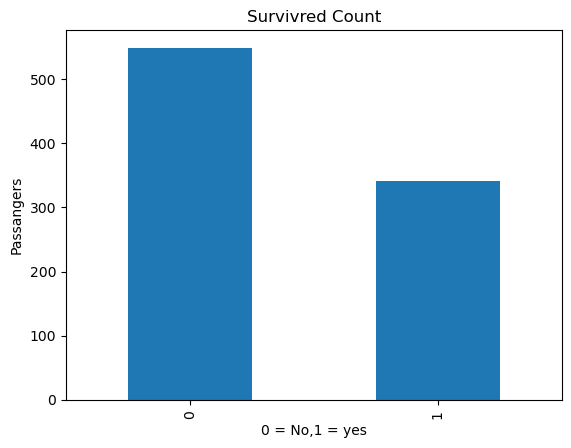

In [24]:
df['Survived'].value_counts().plot(kind='bar')
plt.title('Survivred Count')
plt.xlabel('0 = No,1 = yes')
plt.ylabel('Passangers')
plt.show()

### Survival by Gender

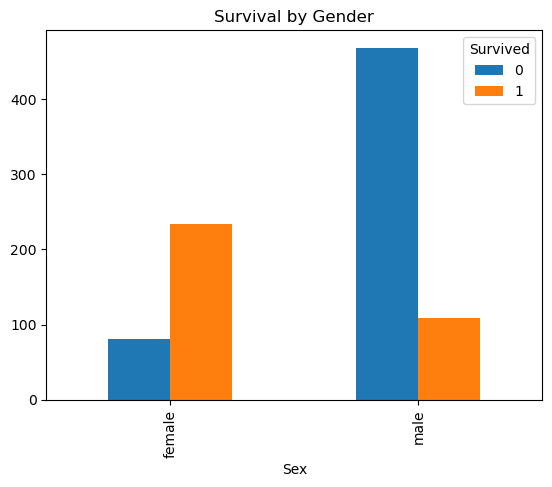

In [28]:
pd.crosstab(df['Sex'],df['Survived']).plot(kind = 'bar')
plt.title('Survival by Gender')
plt.show()

### Survival by Passanger Class

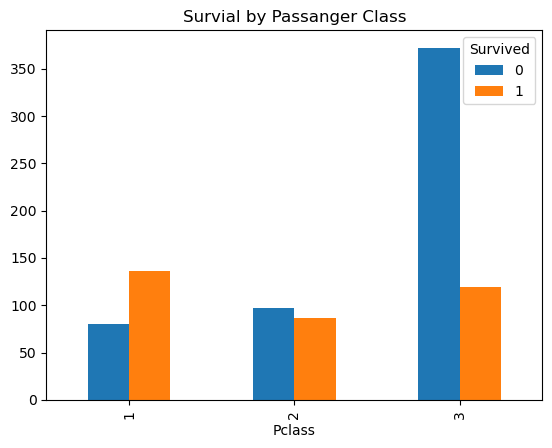

In [31]:
pd.crosstab(df['Pclass'],df['Survived']).plot(kind='bar')
plt.title('Survial by Passanger Class')
plt.show()

# Normalize Data

In [13]:
x = (x - x.mean(axis = 0))/x.std(axis=0)

In [14]:
# sigmoid function

In [15]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

# initialize Weights

In [19]:
rows,cols = x.shape
weights = np.zeros(cols)
bias = 0

learning_rate = 0.1
epochs = 1000

# Train Model

In [21]:
for epoch in range(epochs):
    linear = np.dot(x, weights) + bias
    predictions = sigmoid(linear)

    dw = (1 / rows) * np.dot(x.T, (predictions - y))
    db = (1 / rows) * np.sum(predictions - y)

    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

    if epoch % 100 == 0:
        loss = -np.mean(y * np.log(predictions + 1e-10)+ (1 - y) * np.log(1 - predictions + 1e-10))
        print(f"Epoch {epoch} Loss: {loss:.4f}")

Epoch 0 Loss: 0.6931
Epoch 100 Loss: 0.4635
Epoch 200 Loss: 0.4547
Epoch 300 Loss: 0.4528
Epoch 400 Loss: 0.4523
Epoch 500 Loss: 0.4521
Epoch 600 Loss: 0.4520
Epoch 700 Loss: 0.4520
Epoch 800 Loss: 0.4520
Epoch 900 Loss: 0.4520


# [6]. Prediction Logic

In [23]:
linear = np.dot(x, weights) + bias
predictions = sigmoid(linear)
predicted_classes = []

for p in predictions:
    if p >= 0.5:
        predicted_classes.append(1)
    else:
        predicted_classes.append(0)

predicted_classes = np.array(predicted_classes)

# [7]: Accuracy Calculation

In [24]:
correct = 0 
for actual, predicted in zip(df['Survived'],predictions):
    if actual == predicted:
        correct += 1

accuracy = (correct/len(df))*100
print('accuracy:',round(accuracy,2),'%')

accuracy: 0.0 %


# [9]: Predicted New Passenger

In [27]:
pclass = int(input('Passanger Class:'))
sex = input('Gender(male/female):').lower()
age = float(input('Age:'))
fare = float(input('fare:'))

sex = 1 if sex == 'female' else 0
new_data = np.array([[pclass,sex,age,fare]])
new_data = (new_data - x.mean(axis = 0))/x.std(axis = 0)
result = sigmoid(np.dot(new_data,weights)+bias)

if result >= 0.5:
    print('Prediction:Survived')
else:
    print('Prediction:Not survived')

Passanger Class: 51
Gender(male/female): 21
Age: 1
fare: 1


Prediction:Not survived
